# DDoS Attack Detection using CNN-LSTM Hybrid Model

## Author: Olatunji
## Project: Final Year Cybersecurity / Machine Learning Project

This notebook implements a deep learning-based system for detecting Distributed Denial of Service (DDoS) attacks using CNN, LSTM, and a hybrid CNN-LSTM architecture.


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    Flatten
)

I0000 00:00:1778517856.838015   30401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778517857.822383   30401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778517862.263107   30401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
import glob
import os
import pandas as pd

In [7]:
df = pd.read_csv(
    "dataset/reduced_ddos_dataset.csv",
    low_memory=False
)

df.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,256565,172.16.0.5-192.168.50.1-34012-2334-17,172.16.0.5,34012,192.168.50.1,2334,17,2018-12-01 11:47:08.463789,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_NetBIOS
1,252918,172.16.0.5-192.168.50.1-34013-50170-17,172.16.0.5,34013,192.168.50.1,50170,17,2018-12-01 11:47:08.464316,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_NetBIOS
2,174257,172.16.0.5-192.168.50.1-34014-61534-17,172.16.0.5,34014,192.168.50.1,61534,17,2018-12-01 11:47:08.464472,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_NetBIOS
3,185193,172.16.0.5-192.168.50.1-34015-8930-17,172.16.0.5,34015,192.168.50.1,8930,17,2018-12-01 11:47:08.464520,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_NetBIOS
4,198671,172.16.0.5-192.168.50.1-34016-33040-17,172.16.0.5,34016,192.168.50.1,33040,17,2018-12-01 11:47:08.464925,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_NetBIOS


In [9]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nLabel Distribution:")
# print(df['Label'].value_counts())

Dataset Shape:
(3591694, 88)

Columns:
Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
  

In [10]:
print(df.isnull().sum())

Unnamed: 0         0
Flow ID            0
 Source IP         0
 Source Port       0
 Destination IP    0
                  ..
 Idle Max          0
 Idle Min          0
SimillarHTTP       0
 Inbound           0
 Label             0
Length: 88, dtype: int64


In [11]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Le

In [12]:
df['Label'] = df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

df['Label'].value_counts()

Label
1    3559326
0      32368
Name: count, dtype: int64

In [13]:
df = df.drop([
    'Flow ID',
    ' Source IP',
    ' Destination IP',
    ' Timestamp',
    'Unnamed: 0',
    'SimillarHTTP'
], axis=1, errors='ignore')

In [14]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

In [15]:
df_majority = df[df['Label'] == 1]
df_minority = df[df['Label'] == 0]

df_majority_sampled = df_majority.sample(n=len(df_minority)*5, random_state=42)

df = pd.concat([df_majority_sampled, df_minority])

df['Label'].value_counts()

Label
1    160580
0     32116
Name: count, dtype: int64

In [16]:
X = df.drop('Label', axis=1)
y = df['Label']

In [17]:
X = X.select_dtypes(include=['number'])

print(X.shape)

(192696, 81)


In [18]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)

(154156, 81, 1)


In [22]:
cnn_model = Sequential()

cnn_model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train.shape[1], 1)
))

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Flatten())

cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(1, activation='sigmoid'))

/home/olatunji/ddos/vic/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778518128.557945   30401 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9893 - loss: 0.0354 - val_accuracy: 0.9979 - val_loss: 0.0116
Epoch 2/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9977 - loss: 0.0110 - val_accuracy: 0.9982 - val_loss: 0.0085
Epoch 3/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9978 - loss: 0.0095 - val_accuracy: 0.9982 - val_loss: 0.0082
Epoch 4/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9979 - loss: 0.0092 - val_accuracy: 0.9982 - val_loss: 0.0078
Epoch 5/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9980 - loss: 0.0086 - val_accuracy: 0.9982 - val_loss: 0.0074


In [25]:
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_cnn))

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6595
           1       1.00      1.00      1.00     31945

    accuracy                           1.00     38540
   macro avg       1.00      1.00      1.00     38540
weighted avg       1.00      1.00      1.00     38540



In [26]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    64,
    input_shape=(X_train.shape[1], 1),
    return_sequences=False
))

lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(1, activation='sigmoid'))

/home/olatunji/ddos/vic/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 85s 86ms/step - accuracy: 0.9572 - loss: 0.1462 - val_accuracy: 0.9910 - val_loss: 0.0421
Epoch 2/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.9922 - loss: 0.0349 - val_accuracy: 0.9957 - val_loss: 0.0261
Epoch 3/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9957 - loss: 0.0251 - val_accuracy: 0.9970 - val_loss: 0.0187
Epoch 4/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.9961 - loss: 0.0214 - val_accuracy: 0.9970 - val_loss: 0.0160
Epoch 5/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.9965 - loss: 0.0191 - val_accuracy: 0.9934 - val_loss: 0.0267


In [29]:
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

print(classification_report(y_test, y_pred_lstm))

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      6595
           1       0.99      1.00      1.00     31945

    accuracy                           0.99     38540
   macro avg       0.99      0.99      0.99     38540
weighted avg       0.99      0.99      0.99     38540



In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

hybrid_model = Sequential()

# CNN feature extractor
hybrid_model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train.shape[1], 1)
))

hybrid_model.add(MaxPooling1D(pool_size=2))

# LSTM for temporal learning
hybrid_model.add(LSTM(64))

# Fully connected layers
hybrid_model.add(Dense(64, activation='relu'))
hybrid_model.add(Dropout(0.3))

hybrid_model.add(Dense(1, activation='sigmoid'))

/home/olatunji/ddos/vic/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
hybrid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
hybrid_history = hybrid_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9517 - loss: 0.1406 - val_accuracy: 0.9967 - val_loss: 0.0184
Epoch 2/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9943 - loss: 0.0232 - val_accuracy: 0.9970 - val_loss: 0.0154
Epoch 3/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.9968 - loss: 0.0148 - val_accuracy: 0.9976 - val_loss: 0.0138
Epoch 4/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9971 - loss: 0.0136 - val_accuracy: 0.9980 - val_loss: 0.0100
Epoch 5/5
964/964 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9974 - loss: 0.0127 - val_accuracy: 0.9961 - val_loss: 0.0174


In [33]:
y_pred_hybrid = hybrid_model.predict(X_test)
y_pred_hybrid = (y_pred_hybrid > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_hybrid))

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      6595
           1       1.00      1.00      1.00     31945

    accuracy                           1.00     38540
   macro avg       0.99      0.99      0.99     38540
weighted avg       1.00      1.00      1.00     38540



In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

cnn_results = evaluate_model(y_test, y_pred_cnn)
lstm_results = evaluate_model(y_test, y_pred_lstm)
hybrid_results = evaluate_model(y_test, y_pred_hybrid)

import pandas as pd

results_df = pd.DataFrame({
    "CNN": cnn_results,
    "LSTM": lstm_results,
    "CNN-LSTM": hybrid_results
}).T

results_df

,Accuracy,Precision,Recall,F1-Score
CNN,0.998210,0.999593,0.998247,0.998919
LSTM,0.993098,0.994691,0.996995,0.995841
CNN-LSTM,0.995459,0.995848,0.998685,0.997265


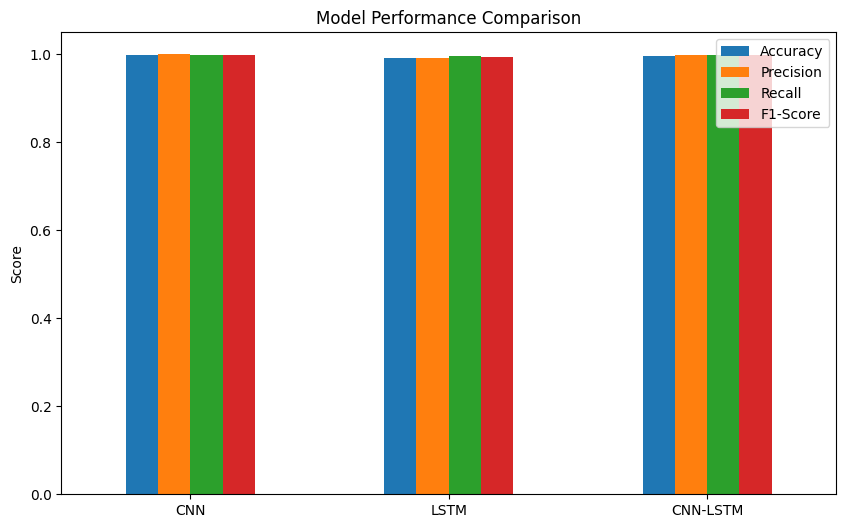

In [33]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

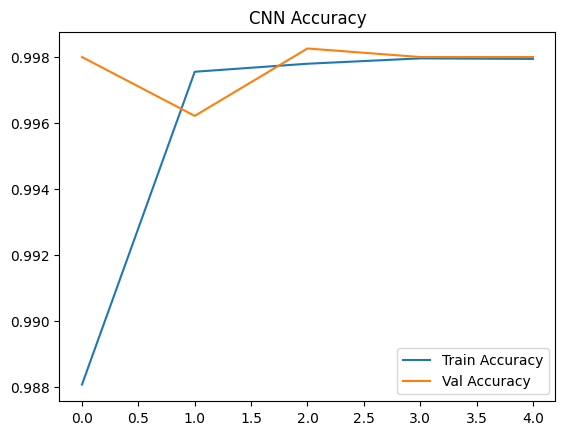

In [34]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy")
plt.legend()
plt.show()

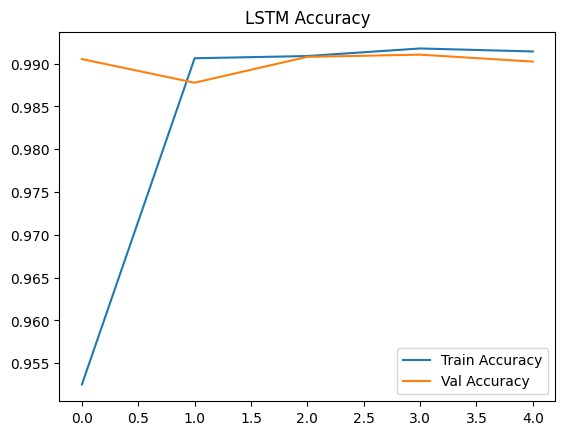

In [35]:
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Accuracy")
plt.legend()
plt.show()

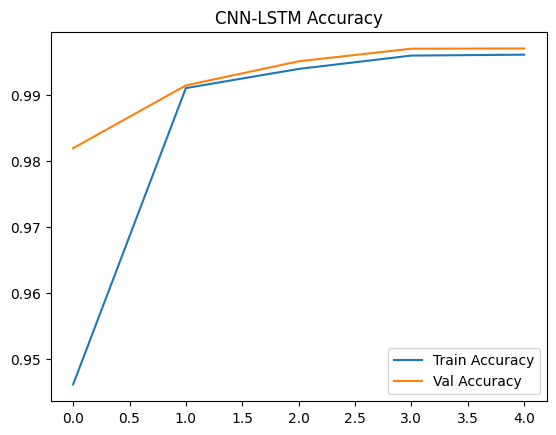

In [36]:
plt.plot(hybrid_history.history['accuracy'], label='Train Accuracy')
plt.plot(hybrid_history.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN-LSTM Accuracy")
plt.legend()
plt.show()

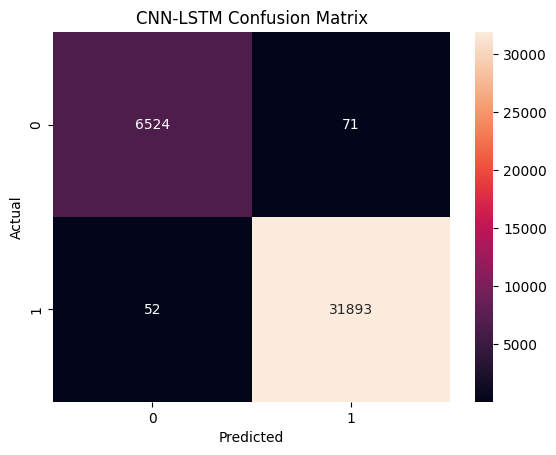

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_hybrid)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN-LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
hybrid_model.save("model/cnn_lstm_ddos_model.h5")

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv(
    "dataset/reduced_ddos_dataset.csv",
    low_memory=False
)

# Fix columns
df.columns = df.columns.str.strip()

# Convert labels
df['Label'] = df['Label'].apply(
    lambda x: 0 if x.strip() == 'BENIGN' else 1
)

# Remove unwanted columns
df = df.drop([
    'Flow ID',
    'Source IP',
    'Destination IP',
    'Timestamp',
    'Unnamed: 0',
    'SimillarHTTP'
], axis=1, errors='ignore')

# Create X
X = df.drop('Label', axis=1)

# Keep numeric columns
X = X.select_dtypes(include=['number'])

# Clean values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Recreate scaler
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Save scaler
joblib.dump(scaler, "model/scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


['scaler.pkl']


NameError: name 'X_train' is not defined

NameError: name 'model' is not defined